In [44]:
!pip -q install pandas scikit-learn joblib matplotlib

In [45]:
from google.colab import files
uploaded = files.upload()

Saving imdb_tvshows.csv to imdb_tvshows (5).csv


In [46]:
import re
import joblib
import pandas as pd
from dataclasses import dataclass
from typing import Tuple, Optional, List

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)

import matplotlib.pyplot as plt

In [47]:
@dataclass(frozen=True)
class Config:
    csv_path: str
    text_col: str = "Review"
    rating_col: str = "Rating (out of 10)"
    show_id_col: str = "Show ID"
    review_id_col: str = "Review ID"

    # 3class thresholds
    neg_max: int = 4
    neutral_min: int = 5
    neutral_max: int = 6
    pos_min: int = 7

    test_size: float = 0.2
    random_state: int = 42

    model_name: str = "logreg"

    ngram_range: Tuple[int, int] = (1, 2)
    min_df: int = 2
    max_df: float = 0.95
    max_features: Optional[int] = 120_000

    model_out: str = "sentiment_tfidf_model.joblib"

In [48]:
_whitespace_re = re.compile(r"\s+")
_html_re = re.compile(r"<[^>]+>")
_non_printing_re = re.compile(r"[\x00-\x1f\x7f-\x9f]")

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = _html_re.sub(" ", text)
    text = _non_printing_re.sub(" ", text)
    text = text.replace("\u2019", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = _whitespace_re.sub(" ", text)
    return text

def label_sentiment_3class(rating: int, cfg: Config) -> str:
    if rating <= cfg.neg_max:
        return "negative"
    if cfg.neutral_min <= rating <= cfg.neutral_max:
        return "neutral"
    if rating >= cfg.pos_min:
        return "positive"
    return "neutral"

def label_sentiment_binary(rating: int, cfg: Config) -> str:
    if rating >= 8:
        return "positive"
    elif rating <= 4:
        return "negative"
    else:
        return None

In [49]:
def load_and_prepare(cfg: Config, task: str = "3class") -> pd.DataFrame:
    df = pd.read_csv(cfg.csv_path)

    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    required = {cfg.text_col, cfg.rating_col, cfg.show_id_col, cfg.review_id_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Found: {list(df.columns)}")

    df[cfg.text_col] = df[cfg.text_col].map(clean_text)
    df[cfg.rating_col] = pd.to_numeric(df[cfg.rating_col], errors="coerce")

    df = df.dropna(subset=[cfg.text_col, cfg.rating_col]).copy()
    df = df[df[cfg.text_col].str.len() > 0].copy()

    if task == "3class":
        df["sentiment"] = df[cfg.rating_col].astype(int).apply(lambda r: label_sentiment_3class(r, cfg))
    elif task == "binary":
        df["sentiment"] = df[cfg.rating_col].astype(int).apply(lambda r: label_sentiment_binary(r, cfg))
    else:
        raise ValueError("task must be '3class' or 'binary'")

    return df

In [50]:
def build_model(cfg: Config) -> Pipeline:
    features = ColumnTransformer(
        transformers=[
            ("text", TfidfVectorizer(
                ngram_range=cfg.ngram_range,
                min_df=cfg.min_df,
                max_df=cfg.max_df,
                max_features=cfg.max_features,
                strip_accents="unicode",
                lowercase=True,
                sublinear_tf=True,
            ), cfg.text_col),
        ],
        remainder="drop",
    )

    if cfg.model_name == "logreg":
        clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    elif cfg.model_name == "linearsvc":
        clf = LinearSVC(class_weight="balanced")
    elif cfg.model_name == "sgd":
        clf = SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            max_iter=2000,
            class_weight="balanced",
            random_state=cfg.random_state,
        )
    else:
        raise ValueError("model_name must be one of: logreg, linearsvc, sgd")

    return Pipeline([("features", features), ("clf", clf)])

def train_and_evaluate(df: pd.DataFrame, cfg: Config, plot_cm: bool = True) -> Pipeline:
    X = df[[cfg.text_col]]
    y = df["sentiment"].astype(str)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=cfg.test_size,
        random_state=cfg.random_state,
        stratify=y,
    )

    pipe = build_model(cfg)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("F1 macro:", round(f1_score(y_test, y_pred, average="macro"), 4))
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

    if plot_cm:
        labels = sorted(y.unique())
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        ConfusionMatrixDisplay(cm, display_labels=labels).plot(values_format="d")
        plt.title("Confusion Matrix")
        plt.show()

    return pipe

,Rating (out of 10),Review,Show ID,Review ID,sentiment
0,9,Andor was every bit as good as I was hoping fo...,tt9253284,rw10514299,positive
1,10,Wow. I just finished episode 12 of the first s...,tt9253284,rw8690571,positive
2,10,Andor Season 2 is the best Star Wars Show ever...,tt9253284,rw10514285,positive
3,9,There were a few episodes I didn't like in bot...,tt9253284,rw10514788,positive
4,9,Didnt like the new movies and even Mandalorian...,tt9253284,rw8665236,positive


Rows: 8319

Sentiment distribution:
 sentiment
positive    5840
negative     870
Name: count, dtype: int64
Accuracy: 0.5931
F1 macro: 0.4063

Classification report:
               precision    recall  f1-score   support

        None     0.2647    0.2795    0.2719       322
    negative     0.2108    0.2011    0.2059       174
    positive     0.7444    0.7380    0.7412      1168

    accuracy                         0.5931      1664
   macro avg     0.4066    0.4062    0.4063      1664
weighted avg     0.5958    0.5931    0.5944      1664



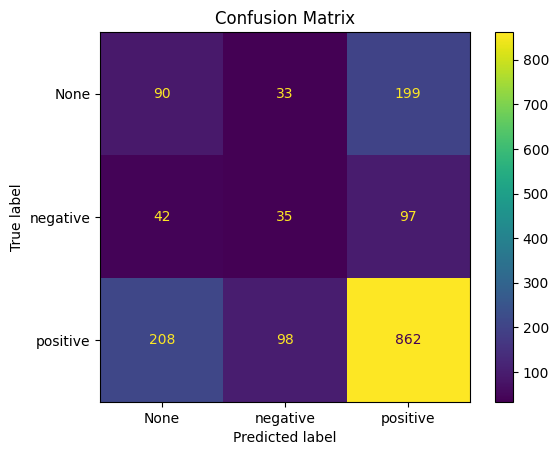

Saved model to: sentiment_tfidf_model.joblib
Saved model to: sentiment_tfidf_model.joblib


In [51]:
# cfg = Config(csv_path="imdb_tvshows.csv")
cfg = Config(csv_path="imdb_tvshows.csv",model_name="logreg")

task = "binary"

df = load_and_prepare(cfg, task=task)

display(df.head())
print("Rows:", len(df))
print("\nSentiment distribution:\n", df["sentiment"].value_counts())

pipe = train_and_evaluate(df, cfg, plot_cm=True)

joblib.dump(pipe, cfg.model_out)
print("Saved model to:", cfg.model_out)

joblib.dump(pipe, cfg.model_out)
print("Saved model to:", cfg.model_out)

In [52]:
def predict_sentiment(pipe: Pipeline, reviews: List[str], cfg: Config) -> pd.DataFrame:
    cleaned = [clean_text(t) for t in reviews]
    X_new = pd.DataFrame({cfg.text_col: cleaned})
    preds = pipe.predict(X_new)

    out = pd.DataFrame({"review": reviews, "predicted_sentiment": preds})

    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        proba = pipe.predict_proba(X_new)
        classes = pipe.named_steps["clf"].classes_
        for i, c in enumerate(classes):
            out[f"p_{c}"] = proba[:, i]
    return out

predict_sentiment(pipe, [
    "I was hooked after episode 1. Great acting.",
    "This was painfully slow and confusing.",
    "Some parts were strong, but overall it was just okay."
], cfg)

,review,predicted_sentiment,p_None,p_negative,p_positive
0,I was hooked after episode 1. Great acting.,positive,0.251154,0.295791,0.453055
1,This was painfully slow and confusing.,positive,0.333597,0.317554,0.348849
2,"Some parts were strong, but overall it was jus...",negative,0.251260,0.393044,0.355696


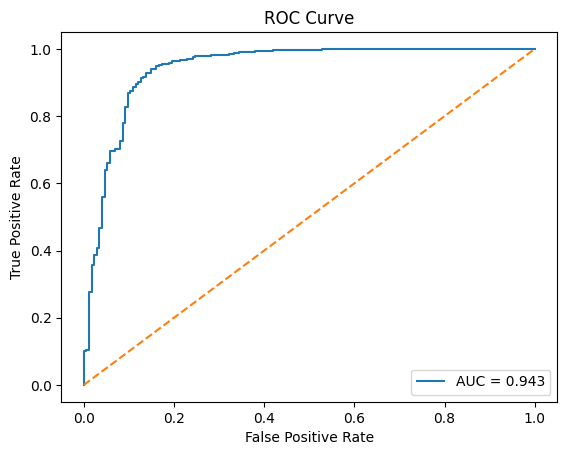

ROC AUC: 0.9428


In [56]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Remove unlabeled rows (None) before splitting / stratifying
df2 = df[df["sentiment"].notna()].copy()

X = df2[[cfg.text_col]]
y = df2["sentiment"].astype(str)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=cfg.test_size,
    random_state=cfg.random_state,
    stratify=y,
)

# Get decision scores
y_scores = pipe.decision_function(X_test)

# If decision_function is multi-class (n, k), select the "positive" column
if y_scores.ndim == 2:
    classes = pipe.named_steps["clf"].classes_
    pos_idx = list(classes).index("positive")
    y_scores = y_scores[:, pos_idx]

# Convert labels to binary 0/1
y_test_binary = (y_test == "positive").astype(int).to_numpy()

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_scores)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC AUC:", round(roc_auc, 4))

After diagnosing label noise from mid-range ratings, I refined the labeling strategy by using only extreme ratings and excluding ambiguous reviews. This improved separability substantially, increasing ROC AUC to 0.943.

This model can be used to prioritize shows generating the strongest sentiment, both positive and negative, by identifying where viewer reactions are most polarized. Surfacing highly positive reviews helps highlight content that resonates and supports marketing or promotion decisions, while concentrated negative sentiment flags titles that may need deeper analysis or product adjustments. Prioritizing extremes allows teams to act quickly on what is working well and what may be hurting engagement or retention.
